In [10]:
import sys
import matplotlib.pyplot as plt

sys.path.append('../..')
import src
import numpy as np

2025-06-12 13:41:48.480747: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-12 13:41:48.490206: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749753708.501575  615231 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749753708.504957  615231 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-12 13:41:48.516766: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

(-100000.0, 100000.0)

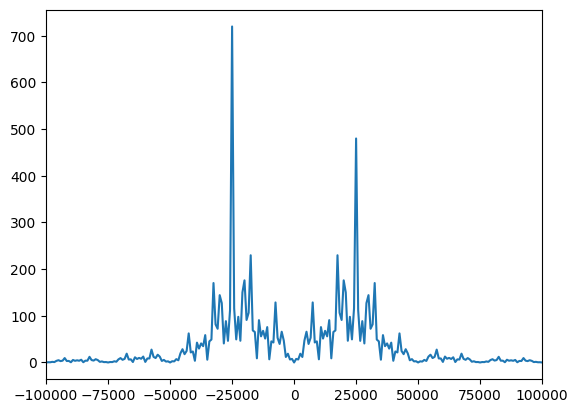

In [ ]:
bit_array = np.random.randint(0,2, 30)

# desired frequency separation in Hz
fs = 1e6
sps = 40

f_dev = fs/sps        # 25e3

# delta_f = 



symbols = np.where(bit_array == 1, 1, -1).astype(np.float32) 
symbols_repeated = np.repeat(symbols,sps)
# 2) true phase step per sample in radians
phase_step = 2*np.pi * f_dev/fs    # = 2π·25 000/1 000 000 = 0.1571

# 3) integrate
phase = np.cumsum(symbols_repeated * phase_step)

sig = np.exp(1j * phase)

freqs = np.fft.fftfreq(len(sig), 1/fs)
freqs   = np.fft.fftshift(freqs)

plt.plot(freqs,np.abs( np.fft.fftshift(np.fft.fft(sig))))
plt.xlim(-100000,100000)



In [ ]:
import numpy as np
from scipy.signal import lfilter
from scipy.signal.windows import gaussian
import matplotlib.pyplot as plt

# 1) parameters
fs   = 1e6        # sample rate
sps  = 40         # samples per symbol
Rs   = fs/sps     # symbol rate = 25 kHz
f_dev= Rs         # deviation = 25 kHz
BT   = 0.3        # bandwidth–time product for the Gaussian pulse
span = 4          # pulse spans 4 symbols

# 2) make bit sequence
bit_array = np.random.randint(0,2, 30)
symbols   = np.where(bit_array==1, +1, -1)

# 3) oversample
sym_up    = np.repeat(symbols, sps)  

# 4) design Gaussian filter
#    - total taps = span symbols worth of samples
ntaps     = span * sps  
#    - the filter’s standard deviation (in samples)
#      α = sqrt(ln2)/(2π·BT)  ⇒ σ = α·sps
alpha     = np.sqrt(np.log(2)) / (2*np.pi * BT)
sigma     = alpha * sps
g_taps    = gaussian(ntaps, std=sigma)
g_taps   /= np.sum(g_taps)        # normalize area to 1

# 5) pulse‐shape (Gaussian filter)
shaped = lfilter(g_taps, 1.0, sym_up)

# 6) integrate to get phase
phase_step = 2*np.pi * (f_dev/fs)
phase      = np.cumsum(shaped * phase_step)

# 7) form the GFSK signal
sig_gfsk   = np.exp(1j * phase)

# 8) inspect spectrum
S    = np.fft.fftshift(np.fft.fft(sig_gfsk))
fvec = np.fft.fftshift(np.fft.fftfreq(len(sig_gfsk), d=1/fs))

plt.plot(fvec/1e3, 20*np.log10(np.abs(S)/np.max(np.abs(S))))
plt.xlim(-100, 100)
plt.ylim(-80, 0)
plt.xlabel("Frequency (kHz)")
plt.ylabel("Normalized PSD (dB)")
plt.title(f"GFSK Spectrum (BT={BT}, span={span} sym)")
plt.grid(True)
plt.show()
